# Ablation Studies — LiveKVQuantP

**Model**: meta-llama/Meta-Llama-3.1-8B-Instruct  
**Task**: narrativeqa (LongBench v1, all samples)  
**Baseline config**: INT4, chunk_size=512, ema_alpha=0.2, clip_factor=4.0, outlier_ratio=1%, use_warmup=True, use_outlier_isolation=True, stats_method=ema_absmax

**Figures** saved to `figures/` for use in `ablation_studies.md`.

In [1]:
import json, os
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import matplotlib.patches as mpatches

matplotlib.rcParams.update({
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'figure.dpi': 130,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

FIG_DIR = 'figures'
os.makedirs(FIG_DIR, exist_ok=True)

# ── Load all ablation results ──
ABL_DIR = '../results/liveKVQuant/ablations'

def load(fname):
    with open(os.path.join(ABL_DIR, fname)) as f:
        d = json.load(f)
    return {
        'score':   d['avg_score'],
        'e2e':     d['avg_end_to_end_latency_ms'],
        'prefill': d['avg_prefill_latency_ms'],
        'decode':  d['avg_decode_latency_ms'],
        'mem':     d['max_peak_memory_mb'],
        'args':    d.get('args', {}),
    }

# Layer 1: Architectural ablations
baseline      = load('20260323_2052_v1_narrativeqa.json')   # alpha=0.1 (new baseline)
no_warmup     = load('20260311_0316_v1_narrativeqa_noWarmup.json')
no_outlier    = load('20260311_0400_v1_narrativeqa_noOutlierIsolation.json')
ema_minmax    = load('20260311_0456_v1_narrativeqa_emaMinMax.json')

# Layer 2: chunk_size sensitivity
cs256  = load('20260311_0638_v1_narrativeqa_chunkSize256.json')
cs512  = baseline  # chunk_size=512 is baseline
cs1024 = load('20260311_0717_v1_narrativeqa_chunkSize1024.json')
cs2048 = load('20260311_0751_v1_narrativeqa_chunkSize2048.json')
cs4096 = load('20260311_0823_v1_narrativeqa_chunkSize4096.json')

# Layer 2: outlier_ratio sensitivity
or_005 = load('20260321_1324_v1_narrativeqa.json')   # 0.5%
or_010 = baseline                                      # 1.0%
or_050 = load('20260321_1414_v1_narrativeqa.json')   # 5.0%

# Layer 2: quant_start_layer (hybrid precision)
qsl_0    = load('20260321_1506_v1_narrativeqa.json')   # layer 0 = full quant
qsl_none = baseline                                      # None = default

# Layer 2: EMA alpha sensitivity
alpha_01 = baseline                                      # alpha=0.1 (= baseline)
alpha_02 = load('20260310_2024_v1_narrativeqa.json')   # alpha=0.2 (old baseline)
alpha_03 = load('20260323_2158_v1_narrativeqa.json')   # alpha=0.3
alpha_05 = load('20260323_2247_v1_narrativeqa.json')   # alpha=0.5

# Layer 2: Clip factor sensitivity
clip_30 = load('20260324_0028_v1_narrativeqa.json')    # clip=3.0
clip_40 = baseline                                       # clip=4.0
clip_50 = load('20260323_2338_v1_narrativeqa.json')    # clip=5.0
clip_70 = load('20260324_0118_v1_narrativeqa.json')    # clip=7.0

print('All ablation files loaded (17 configs).')

All ablation files loaded (17 configs).


---
## 1. Architectural Ablation (Layer 1)

Each bar removes or swaps one component from the baseline.

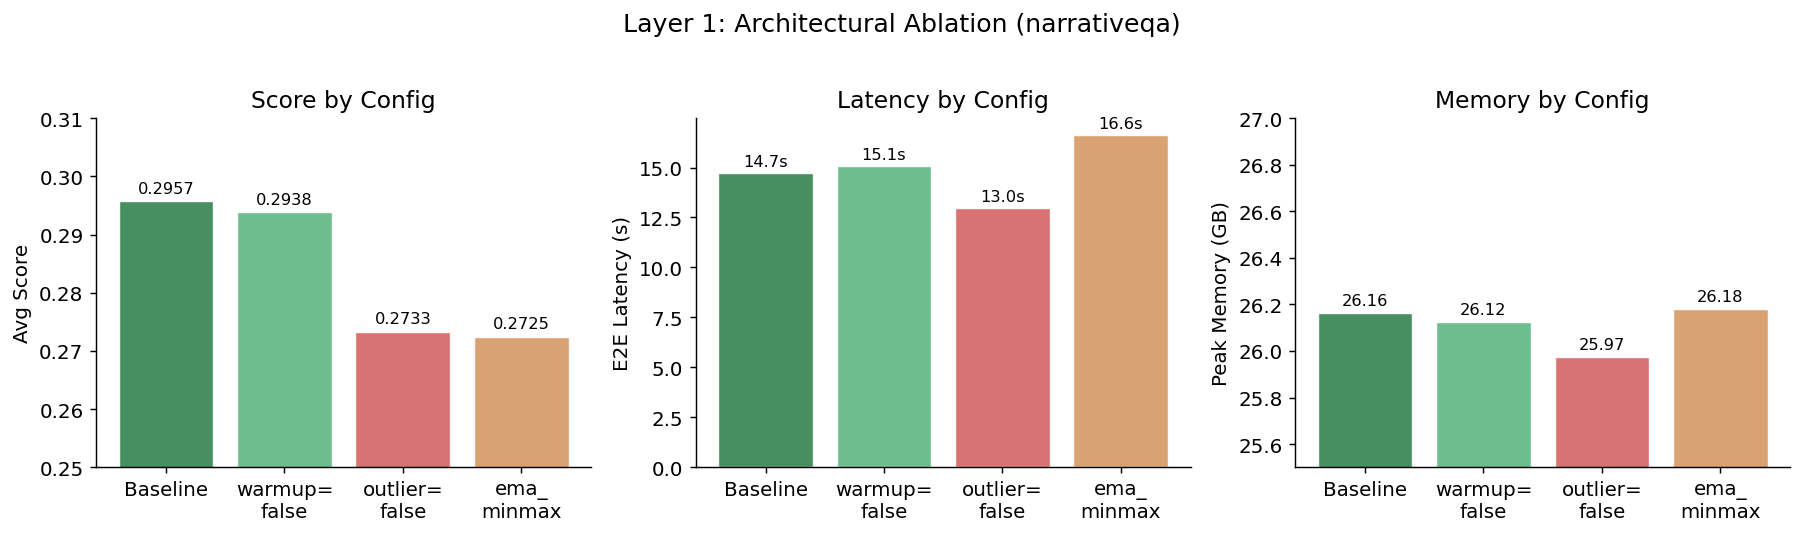

In [2]:
# ── Layer 1: Architectural ablation ──arch_configs = [    ('Baseline', baseline),    ('warmup=\nfalse', no_warmup),    ('outlier=\nfalse', no_outlier),    ('ema_\nminmax', ema_minmax),    ('qsl=0\n(full quant)', qsl_0),]arch_labels = [c[0] for c in arch_configs]arch_scores = [c[1]['score'] for c in arch_configs]arch_e2e    = [c[1]['e2e'] / 1000 for c in arch_configs]arch_mem    = [c[1]['mem'] / 1024 for c in arch_configs]fig, axes = plt.subplots(1, 3, figsize=(15, 4))colors = ['#2d7e4a', '#5bb37f', '#d45f5f', '#d4955f', '#9467bd']# Scoreax = axes[0]bars = ax.bar(arch_labels, arch_scores, color=colors, alpha=0.88, edgecolor='white', linewidth=0.8)ax.set_ylabel('Avg Score')ax.set_title('Score by Config')ax.set_ylim(0.25, 0.31)for b, v in zip(bars, arch_scores):    ax.text(b.get_x() + b.get_width()/2, v + 0.001, f'{v:.4f}', ha='center', va='bottom', fontsize=9)# E2E Latencyax = axes[1]bars = ax.bar(arch_labels, arch_e2e, color=colors, alpha=0.88, edgecolor='white', linewidth=0.8)ax.set_ylabel('E2E Latency (s)')ax.set_title('Latency by Config')for b, v in zip(bars, arch_e2e):    ax.text(b.get_x() + b.get_width()/2, v + 0.2, f'{v:.1f}s', ha='center', va='bottom', fontsize=9)# Peak Memoryax = axes[2]bars = ax.bar(arch_labels, arch_mem, color=colors, alpha=0.88, edgecolor='white', linewidth=0.8)ax.set_ylabel('Peak Memory (GB)')ax.set_title('Memory by Config')ax.set_ylim(25.5, 27)for b, v in zip(bars, arch_mem):    ax.text(b.get_x() + b.get_width()/2, v + 0.02, f'{v:.2f}', ha='center', va='bottom', fontsize=9)fig.suptitle('Layer 1: Architectural Ablation (narrativeqa)', fontsize=14, y=1.02)fig.tight_layout()fig.savefig(f'{FIG_DIR}/ablation_architecture.png', bbox_inches='tight', dpi=150)plt.show()

---
## 2. Chunk Size Sensitivity (Layer 2)

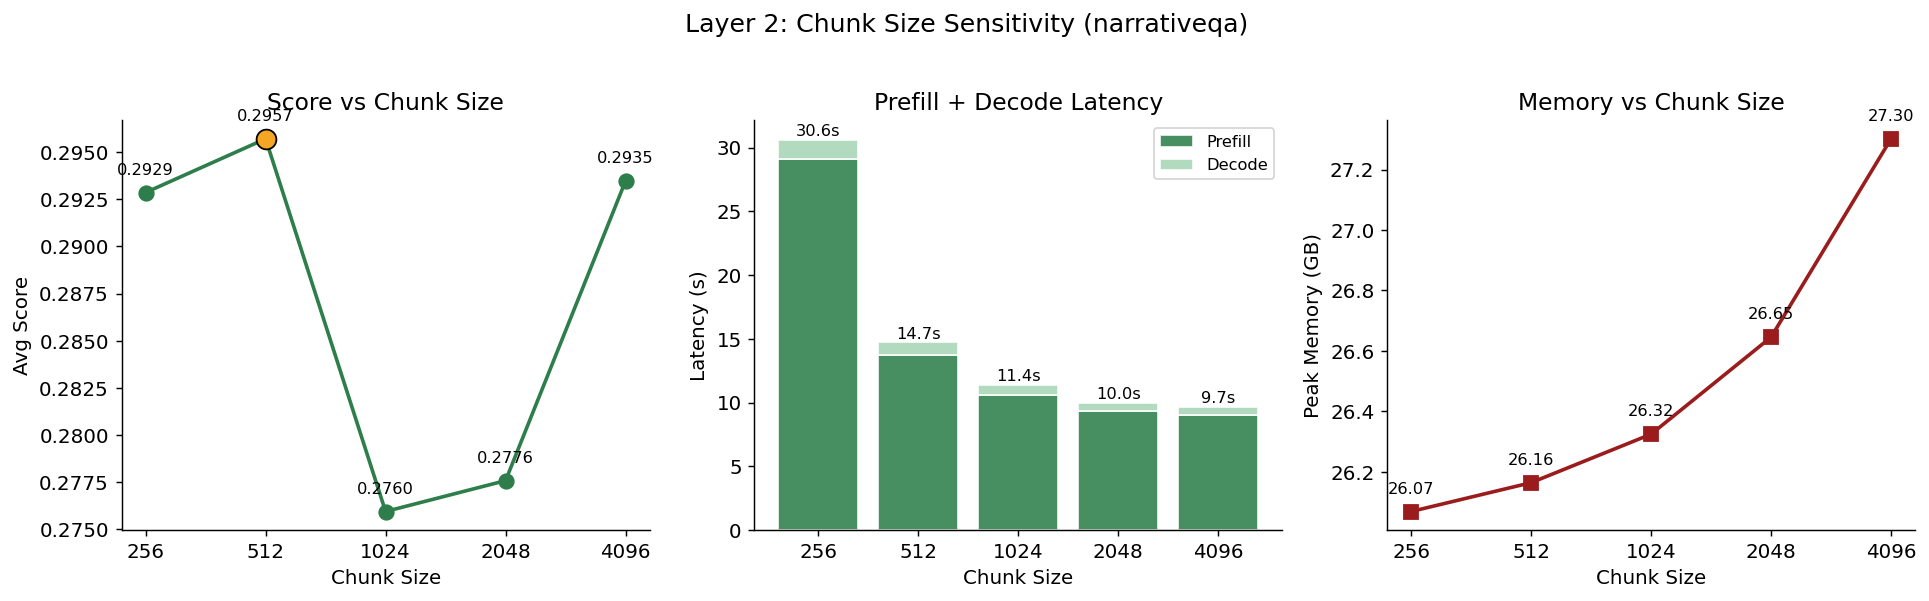

In [3]:
# ── Layer 2: chunk_size ──
cs_configs = [
    (256, cs256), (512, cs512), (1024, cs1024), (2048, cs2048), (4096, cs4096),
]
cs_labels  = [str(c[0]) for c in cs_configs]
cs_scores  = [c[1]['score'] for c in cs_configs]
cs_e2e     = [c[1]['e2e'] / 1000 for c in cs_configs]
cs_prefill = [c[1]['prefill'] / 1000 for c in cs_configs]
cs_decode  = [c[1]['decode'] / 1000 for c in cs_configs]
cs_mem     = [c[1]['mem'] / 1024 for c in cs_configs]

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

color_main = '#2d7e4a'
color_highlight = '#f5a623'
cs_colors = [color_highlight if s == 512 else color_main for s in [256,512,1024,2048,4096]]

# Score vs chunk_size (line + markers)
ax = axes[0]
ax.plot(cs_labels, cs_scores, 'o-', color=color_main, markersize=8, linewidth=2)
ax.scatter(['512'], [cs_scores[1]], color=color_highlight, s=120, zorder=5, edgecolors='black')
ax.set_xlabel('Chunk Size')
ax.set_ylabel('Avg Score')
ax.set_title('Score vs Chunk Size')
for i, (l, v) in enumerate(zip(cs_labels, cs_scores)):
    ax.annotate(f'{v:.4f}', (l, v), textcoords='offset points', xytext=(0, 10), ha='center', fontsize=9)

# Latency (stacked prefill + decode)
ax = axes[1]
x = np.arange(len(cs_labels))
ax.bar(x, cs_prefill, label='Prefill', color='#2d7e4a', alpha=0.88, edgecolor='white')
ax.bar(x, cs_decode, bottom=cs_prefill, label='Decode', color='#a8d5b5', alpha=0.88, edgecolor='white')
ax.set_xticks(x)
ax.set_xticklabels(cs_labels)
ax.set_xlabel('Chunk Size')
ax.set_ylabel('Latency (s)')
ax.set_title('Prefill + Decode Latency')
ax.legend(fontsize=9)
for i, v in enumerate(cs_e2e):
    ax.text(i, v + 0.3, f'{v:.1f}s', ha='center', fontsize=9)

# Memory
ax = axes[2]
ax.plot(cs_labels, cs_mem, 's-', color='#9b1c1c', markersize=8, linewidth=2)
ax.set_xlabel('Chunk Size')
ax.set_ylabel('Peak Memory (GB)')
ax.set_title('Memory vs Chunk Size')
for i, (l, v) in enumerate(zip(cs_labels, cs_mem)):
    ax.annotate(f'{v:.2f}', (l, v), textcoords='offset points', xytext=(0, 10), ha='center', fontsize=9)

fig.suptitle('Layer 2: Chunk Size Sensitivity (narrativeqa)', fontsize=14, y=1.02)
fig.tight_layout()
fig.savefig(f'{FIG_DIR}/ablation_chunk_size.png', bbox_inches='tight', dpi=150)
plt.show()

---
## 3. Outlier Ratio Sensitivity (Layer 2)

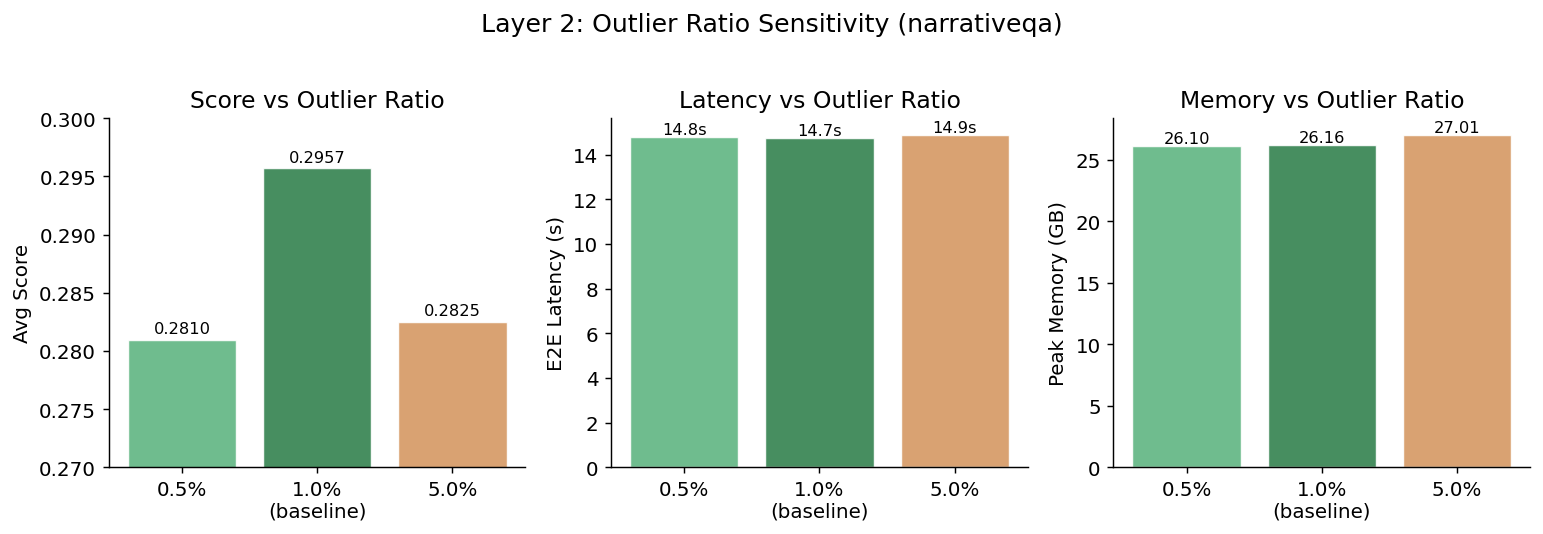

In [4]:
# ── Layer 2: outlier_ratio ──
or_configs = [
    ('0.5%', or_005), ('1.0%\n(baseline)', or_010), ('5.0%', or_050),
]
or_labels  = [c[0] for c in or_configs]
or_scores  = [c[1]['score'] for c in or_configs]
or_e2e     = [c[1]['e2e'] / 1000 for c in or_configs]
or_mem     = [c[1]['mem'] / 1024 for c in or_configs]

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
or_colors = ['#5bb37f', '#2d7e4a', '#d4955f']

for ax, vals, ylabel, title, fmt in [
    (axes[0], or_scores, 'Avg Score', 'Score vs Outlier Ratio', '.4f'),
    (axes[1], or_e2e, 'E2E Latency (s)', 'Latency vs Outlier Ratio', '.1f'),
    (axes[2], or_mem, 'Peak Memory (GB)', 'Memory vs Outlier Ratio', '.2f'),
]:
    bars = ax.bar(or_labels, vals, color=or_colors, alpha=0.88, edgecolor='white', linewidth=0.8)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    for b, v in zip(bars, vals):
        label = f'{v:{fmt}}' + ('s' if 'Latency' in ylabel else '')
        ax.text(b.get_x() + b.get_width()/2, v + (max(vals)-min(vals))*0.02,
                label, ha='center', va='bottom', fontsize=9)

axes[0].set_ylim(0.27, 0.30)

fig.suptitle('Layer 2: Outlier Ratio Sensitivity (narrativeqa)', fontsize=14, y=1.02)
fig.tight_layout()
fig.savefig(f'{FIG_DIR}/ablation_outlier_ratio.png', bbox_inches='tight', dpi=150)
plt.show()

---
## 4. Hybrid Precision — quant_start_layer (Layer 2)

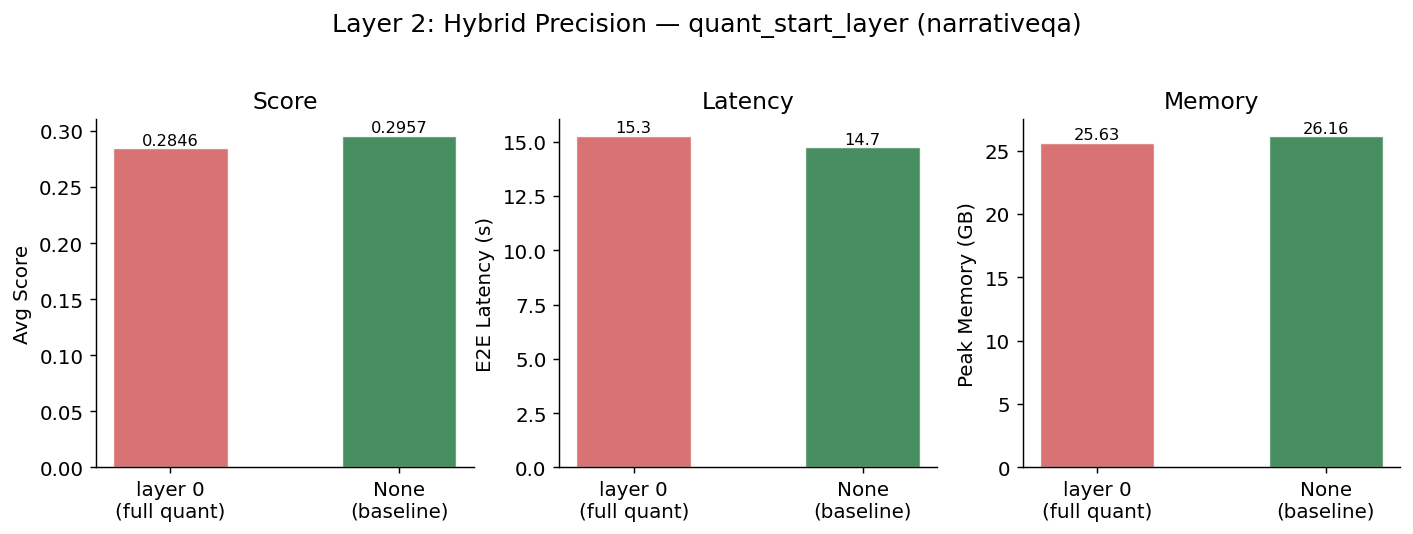

In [5]:
# ── Layer 2: quant_start_layer ──
hp_configs = [
    ('layer 0\n(full quant)', qsl_0), ('None\n(baseline)', qsl_none),
]
hp_labels  = [c[0] for c in hp_configs]
hp_scores  = [c[1]['score'] for c in hp_configs]
hp_e2e     = [c[1]['e2e'] / 1000 for c in hp_configs]
hp_mem     = [c[1]['mem'] / 1024 for c in hp_configs]

fig, axes = plt.subplots(1, 3, figsize=(11, 4))
hp_colors = ['#d45f5f', '#2d7e4a']

for ax, vals, ylabel, title, fmt in [
    (axes[0], hp_scores, 'Avg Score', 'Score', '.4f'),
    (axes[1], hp_e2e, 'E2E Latency (s)', 'Latency', '.1f'),
    (axes[2], hp_mem, 'Peak Memory (GB)', 'Memory', '.2f'),
]:
    bars = ax.bar(hp_labels, vals, color=hp_colors, alpha=0.88, edgecolor='white', linewidth=0.8, width=0.5)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    for b, v in zip(bars, vals):
        label = f'{v:{fmt}}'
        ax.text(b.get_x() + b.get_width()/2, v + (max(vals)-min(vals))*0.02,
                label, ha='center', va='bottom', fontsize=9)

fig.suptitle('Layer 2: Hybrid Precision — quant_start_layer (narrativeqa)', fontsize=14, y=1.02)
fig.tight_layout()
fig.savefig(f'{FIG_DIR}/ablation_hybrid_precision.png', bbox_inches='tight', dpi=150)
plt.show()

---
## 5. EMA Alpha Sensitivity (Layer 2)

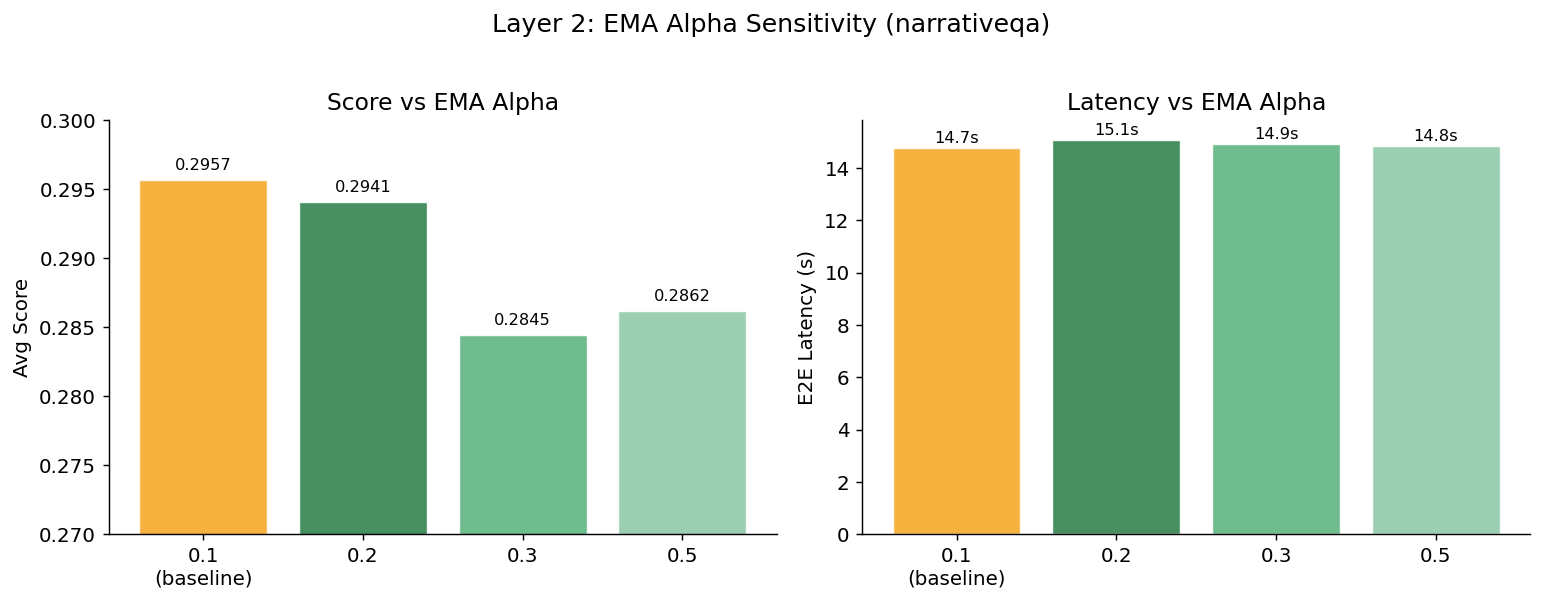

In [6]:
# ── Layer 2: EMA alpha ──
al_configs = [('0.1\n(baseline)', alpha_01), ('0.2', alpha_02), ('0.3', alpha_03), ('0.5', alpha_05)]
al_labels  = [c[0] for c in al_configs]
al_scores  = [c[1]['score'] for c in al_configs]
al_e2e     = [c[1]['e2e'] / 1000 for c in al_configs]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
al_colors = ['#f5a623', '#2d7e4a', '#5bb37f', '#8fc9a8']

ax = axes[0]
bars = ax.bar(al_labels, al_scores, color=al_colors, alpha=0.88, edgecolor='white', linewidth=0.8)
ax.set_ylabel('Avg Score'); ax.set_title('Score vs EMA Alpha'); ax.set_ylim(0.27, 0.30)
for b, v in zip(bars, al_scores):
    ax.text(b.get_x()+b.get_width()/2, v+0.0005, f'{v:.4f}', ha='center', va='bottom', fontsize=9)

ax = axes[1]
bars = ax.bar(al_labels, al_e2e, color=al_colors, alpha=0.88, edgecolor='white', linewidth=0.8)
ax.set_ylabel('E2E Latency (s)'); ax.set_title('Latency vs EMA Alpha')
for b, v in zip(bars, al_e2e):
    ax.text(b.get_x()+b.get_width()/2, v+0.1, f'{v:.1f}s', ha='center', va='bottom', fontsize=9)

fig.suptitle('Layer 2: EMA Alpha Sensitivity (narrativeqa)', fontsize=14, y=1.02)
fig.tight_layout()
fig.savefig(f'{FIG_DIR}/ablation_ema_alpha.png', bbox_inches='tight', dpi=150)
plt.show()

---
## 6. Clip Factor Sensitivity (Layer 2)

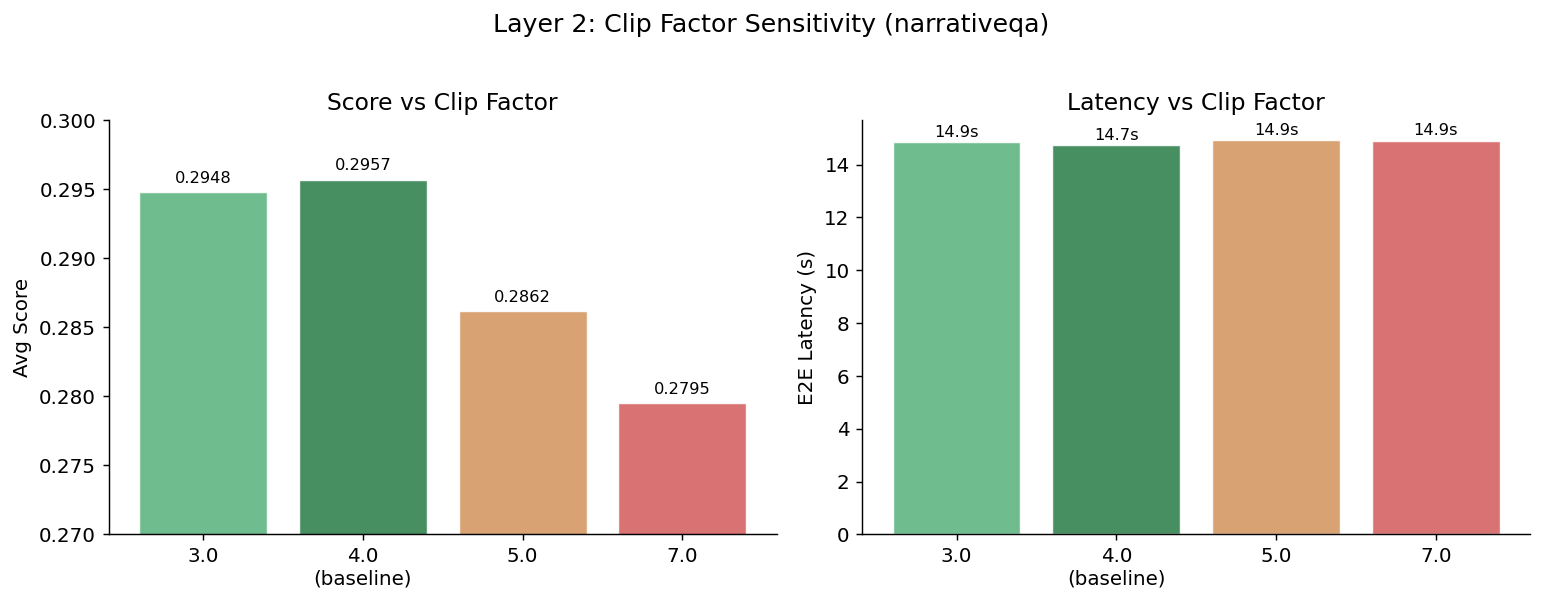

In [7]:
# ── Layer 2: Clip factor ──
cl_configs = [('3.0', clip_30), ('4.0\n(baseline)', clip_40), ('5.0', clip_50), ('7.0', clip_70)]
cl_labels  = [c[0] for c in cl_configs]
cl_scores  = [c[1]['score'] for c in cl_configs]
cl_e2e     = [c[1]['e2e'] / 1000 for c in cl_configs]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
cl_colors = ['#5bb37f', '#2d7e4a', '#d4955f', '#d45f5f']

ax = axes[0]
bars = ax.bar(cl_labels, cl_scores, color=cl_colors, alpha=0.88, edgecolor='white', linewidth=0.8)
ax.set_ylabel('Avg Score'); ax.set_title('Score vs Clip Factor'); ax.set_ylim(0.27, 0.30)
for b, v in zip(bars, cl_scores):
    ax.text(b.get_x()+b.get_width()/2, v+0.0005, f'{v:.4f}', ha='center', va='bottom', fontsize=9)

ax = axes[1]
bars = ax.bar(cl_labels, cl_e2e, color=cl_colors, alpha=0.88, edgecolor='white', linewidth=0.8)
ax.set_ylabel('E2E Latency (s)'); ax.set_title('Latency vs Clip Factor')
for b, v in zip(bars, cl_e2e):
    ax.text(b.get_x()+b.get_width()/2, v+0.1, f'{v:.1f}s', ha='center', va='bottom', fontsize=9)

fig.suptitle('Layer 2: Clip Factor Sensitivity (narrativeqa)', fontsize=14, y=1.02)
fig.tight_layout()
fig.savefig(f'{FIG_DIR}/ablation_clip_factor.png', bbox_inches='tight', dpi=150)
plt.show()

---
## 7. Score–Latency–Memory Trade-off (All 17 Configs)

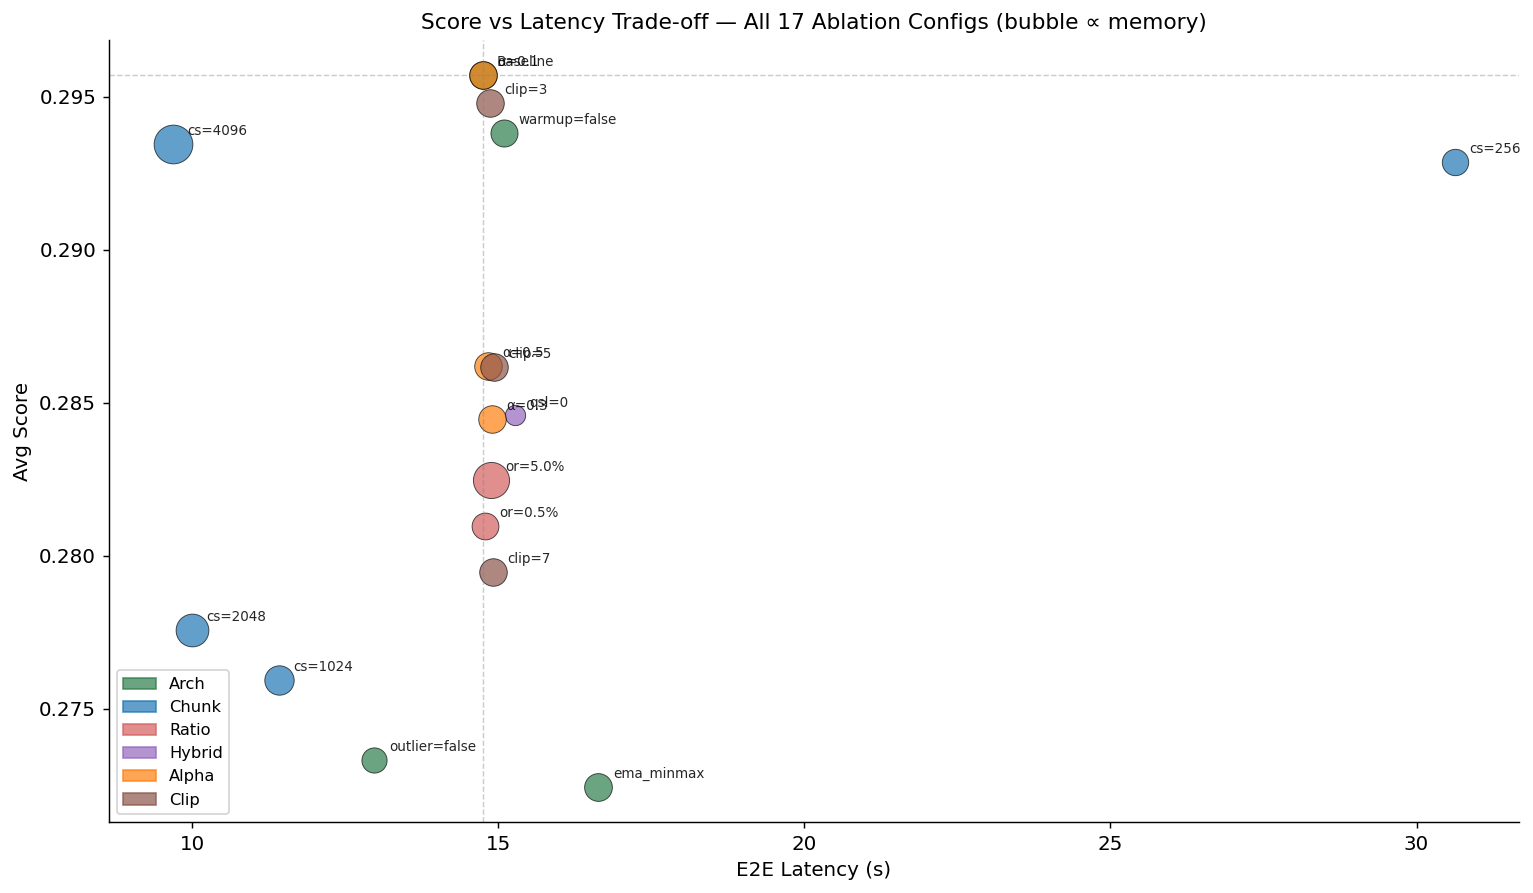

In [8]:
all_configs = {
    'Baseline':        baseline,
    'warmup=false':    no_warmup,
    'outlier=false':   no_outlier,
    'ema_minmax':      ema_minmax,
    'cs=256':          cs256,
    'cs=1024':         cs1024,
    'cs=2048':         cs2048,
    'cs=4096':         cs4096,
    'or=0.5%':         or_005,
    'or=5.0%':         or_050,
    'qsl=0':           qsl_0,
    'α=0.1':           alpha_01,
    'α=0.3':           alpha_03,
    'α=0.5':           alpha_05,
    'clip=3':          clip_30,
    'clip=5':          clip_50,
    'clip=7':          clip_70,
}

group_colors = {
    'arch':  '#2d7e4a', 'chunk': '#1f77b4', 'ratio': '#d45f5f',
    'hybrid':'#9467bd', 'alpha': '#ff7f0e', 'clip':  '#8c564b',
}
config_groups = {
    'Baseline': 'arch', 'warmup=false': 'arch', 'outlier=false': 'arch', 'ema_minmax': 'arch',
    'cs=256': 'chunk', 'cs=1024': 'chunk', 'cs=2048': 'chunk', 'cs=4096': 'chunk',
    'or=0.5%': 'ratio', 'or=5.0%': 'ratio',
    'qsl=0': 'hybrid',
    'α=0.1': 'alpha', 'α=0.3': 'alpha', 'α=0.5': 'alpha',
    'clip=3': 'clip', 'clip=5': 'clip', 'clip=7': 'clip',
}

fig, ax = plt.subplots(figsize=(12, 7))
for name, data in all_configs.items():
    x = data['e2e'] / 1000
    y = data['score']
    s = max((data['mem'] / 1024 - 25) * 200, 30)
    c = group_colors[config_groups[name]]
    ax.scatter(x, y, s=s, c=c, alpha=0.7, edgecolors='black', linewidth=0.5)
    ax.annotate(name, (x, y), textcoords='offset points', xytext=(8, 5), fontsize=7.5, alpha=0.85)

legend_patches = [mpatches.Patch(color=v, label=k.title(), alpha=0.7) for k, v in group_colors.items()]
ax.legend(handles=legend_patches, loc='lower left', fontsize=9)
ax.set_xlabel('E2E Latency (s)')
ax.set_ylabel('Avg Score')
ax.set_title('Score vs Latency Trade-off — All 17 Ablation Configs (bubble ∝ memory)', fontsize=12)
ax.axhline(y=baseline['score'], color='gray', linestyle='--', alpha=0.4, linewidth=0.8)
ax.axvline(x=baseline['e2e']/1000, color='gray', linestyle='--', alpha=0.4, linewidth=0.8)

fig.tight_layout()
fig.savefig(f'{FIG_DIR}/ablation_tradeoff.png', bbox_inches='tight', dpi=150)
plt.show()

---
## Summary Table (All 17 Configs)

In [9]:
print(f'{"Config":<25s} {"Score":>8s} {"Δ Score":>9s} {"E2E (s)":>8s} {"Prefill":>8s} {"Decode":>8s} {"Mem (GB)":>9s}')
print('-' * 78)

all_rows = [
    ('Baseline (α=0.1)',       baseline),
    ('warmup=false',        no_warmup),
    ('outlier=false',       no_outlier),
    ('ema_minmax',          ema_minmax),
    ('chunk_size=256',      cs256),
    ('chunk_size=1024',     cs1024),
    ('chunk_size=2048',     cs2048),
    ('chunk_size=4096',     cs4096),
    ('outlier_ratio=0.5%',  or_005),
    ('outlier_ratio=5.0%',  or_050),
    ('quant_start_layer=0', qsl_0),
    ('ema_alpha=0.1',       alpha_01),
    ('ema_alpha=0.3',       alpha_03),
    ('ema_alpha=0.5',       alpha_05),
    ('clip_factor=3.0',     clip_30),
    ('clip_factor=5.0',     clip_50),
    ('clip_factor=7.0',     clip_70),
]

bs = baseline['score']
for name, d in all_rows:
    delta = d['score'] - bs
    print(f'{name:<25s} {d["score"]:>8.4f} {delta:>+9.4f} {d["e2e"]/1000:>8.1f} {d["prefill"]/1000:>8.1f} {d["decode"]/1000:>8.1f} {d["mem"]/1024:>9.2f}')

Config                       Score   Δ Score  E2E (s)  Prefill   Decode  Mem (GB)
------------------------------------------------------------------------------
Baseline (α=0.1)            0.2957   +0.0000     14.7     13.8      1.0     26.16
warmup=false                0.2938   -0.0019     15.1     14.1      1.0     26.12
outlier=false               0.2733   -0.0224     13.0     12.0      0.9     25.97
ema_minmax                  0.2725   -0.0232     16.6     15.6      1.0     26.18
chunk_size=256              0.2929   -0.0028     30.6     29.1      1.5     26.07
chunk_size=1024             0.2760   -0.0198     11.4     10.6      0.8     26.32
chunk_size=2048             0.2776   -0.0181     10.0      9.3      0.7     26.65
chunk_size=4096             0.2935   -0.0022      9.7      9.0      0.7     27.30
outlier_ratio=0.5%          0.2810   -0.0147     14.8     13.8      1.0     26.10
outlier_ratio=5.0%          0.2825   -0.0132     14.9     13.9      1.0     27.01
quant_start_layer=0